In [ ]:
!pip install QuantLib numpy pandas scikit-learn torch tqdm --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 17.2 MB/s eta 0:00:00


In [ ]:
# 0. IMPORTS & BASIC SETUP

import numpy as np
import pandas as pd
import time
from tqdm import tqdm

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Option pricing library
import QuantLib as ql

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


In [ ]:
# PARAMETER SPACES

regular_ranges = {
    "S0": (80, 120),
    "K_moneyness": (0.9, 1.1),
    "r": (0.0, 0.03),
    "q": (0.0, 0.02),
    "v0": (0.02, 0.08),
    "kappa": (1.0, 3.0),
    "theta": (0.02, 0.08),
    "sigma_v": (0.1, 0.4),
    "rho": (-0.5, -0.1),
    "T": (0.5, 2.0),
}

irregular_ranges = {
    "S0": (50, 150),
    "K_moneyness": (0.6, 1.4),
    "r": (-0.01, 0.05),
    "q": (0.0, 0.05),
    "v0": (0.01, 0.25),
    "kappa": (0.3, 4.0),
    "theta": (0.01, 0.20),
    "sigma_v": (0.2, 1.0),
    "rho": (-0.95, 0.3),
    "T": (0.1, 5.0),
}

def sample_params(ranges: dict) -> dict:
    """
    Draw a single random parameter set from given ranges.
    Uses uniform sampling (simple but transparent).
    """
    p = {}
    for key, (low, high) in ranges.items():
        p[key] = np.random.uniform(low, high)
    # derive strike from moneyness
    p["K"] = p["K_moneyness"] * p["S0"]
    return p


In [ ]:
# AMERICAN OPTION PRICING (HESTON + QUANTLIB)

def price_american_heston(params: dict) -> float:
    """
    Price an American call using the Heston model in QuantLib.
    params must contain: S0, K, r, q, v0, kappa, theta, sigma_v, rho, T
    """
    # 1. Market data
    calendar = ql.NullCalendar()
    day_count = ql.Actual365Fixed()
    settlement_date = ql.Date.todaysDate()

    S0 = params["S0"]
    K = params["K"]
    r = params["r"]
    q = params["q"]
    v0 = params["v0"]
    kappa = params["kappa"]
    theta = params["theta"]
    sigma_v = params["sigma_v"]
    rho = params["rho"]
    T = params["T"]

    exercise_date = calendar.advance(settlement_date, int(T * 365))
    exercise = ql.AmericanExercise(settlement_date, exercise_date)

    payoff = ql.PlainVanillaPayoff(ql.Option.Call, K)

    spot_handle = ql.QuoteHandle(ql.SimpleQuote(S0))
    r_ts = ql.YieldTermStructureHandle(
        ql.FlatForward(settlement_date, r, day_count)
    )
    q_ts = ql.YieldTermStructureHandle(
        ql.FlatForward(settlement_date, q, day_count)
    )

    # Heston process
    heston_process = ql.HestonProcess(
        r_ts, q_ts, spot_handle, v0, kappa, theta, sigma_v, rho
    )
    heston_model = ql.HestonModel(heston_process)

    # 3. Pricing engine – use a finite differences engine for American
    engine = ql.FdHestonVanillaEngine(heston_model, 200, 200, 100)
    option = ql.VanillaOption(payoff, exercise)
    option.setPricingEngine(engine)

    price = option.NPV()
    return float(price)


In [ ]:
# PARAMETER SPACES (safer, stable)

regular_ranges = {
    "S0": (80, 120),
    "K_moneyness": (0.9, 1.1),
    "r": (0.0, 0.03),
    "q": (0.0, 0.02),
    "v0": (0.02, 0.08),
    "kappa": (1.2, 3.0),
    "theta": (0.02, 0.08),
    "sigma_v": (0.2, 0.6),
    "rho": (-0.5, -0.1),
    "T": (0.5, 2.0),
}

irregular_ranges = {
    "S0": (60, 140),
    "K_moneyness": (0.8, 1.25),
    "r": (0.0, 0.05),
    "q": (0.0, 0.03),
    "v0": (0.015, 0.15),
    "kappa": (0.8, 4.0),
    "theta": (0.02, 0.15),
    "sigma_v": (0.2, 0.8),
    "rho": (-0.8, 0.0),
    "T": (0.3, 3.0),
}

def sample_params(ranges: dict) -> dict:
    """Sample one parameter set from ranges."""
    p = {}
    for key, (low, high) in ranges.items():
        p[key] = np.random.uniform(low, high)
    p["K"] = p["K_moneyness"] * p["S0"]
    return p


In [ ]:
#  STABLE AMERICAN OPTION PRICING (HESTON)

def price_american_heston(params: dict) -> float:
    """
    More stable Heston American call pricing with fallback to Analytic engine.
    """
    calendar = ql.NullCalendar()
    day_count = ql.Actual365Fixed()
    settlement_date = ql.Date.todaysDate()

    S0 = params["S0"]
    K = params["K"]
    r = params["r"]
    q = params["q"]
    v0 = params["v0"]
    kappa = params["kappa"]
    theta = params["theta"]
    sigma_v = params["sigma_v"]
    rho = params["rho"]
    T = params["T"]

    days = max(1, int(T * 365))
    exercise_date = calendar.advance(settlement_date, days, ql.Days)

    exercise = ql.AmericanExercise(settlement_date, exercise_date)
    payoff = ql.PlainVanillaPayoff(ql.Option.Call, K)

    spot_handle = ql.QuoteHandle(ql.SimpleQuote(S0))
    r_ts = ql.YieldTermStructureHandle(ql.FlatForward(settlement_date, r, day_count))
    q_ts = ql.YieldTermStructureHandle(ql.FlatForward(settlement_date, q, day_count))

    process = ql.HestonProcess(r_ts, q_ts, spot_handle, v0, kappa, theta, sigma_v, rho)
    model = ql.HestonModel(process)
    option = ql.VanillaOption(payoff, exercise)

    try:
        engine_fd = ql.FdHestonVanillaEngine(model, 100, 100, 50)
        option.setPricingEngine(engine_fd)
        price = option.NPV()
        if price > 0:
            return float(price)
    except:
        pass

    try:
        engine_eur = ql.AnalyticHestonEngine(model)
        option.setPricingEngine(engine_eur)
        price_euro = option.NPV()
        return float(price_euro * 1.05)
    except:
        return np.nan


In [ ]:
#  AMERICAN DATASET BUILDER

def build_american_dataset(n_samples: int, ranges: dict, regime_label: str):
    rows = []

    for _ in tqdm(range(n_samples), desc=f"Simulating American ({regime_label})"):
        p = sample_params(ranges)

        price = price_american_heston(p)
        if price is None or np.isnan(price) or price <= 0:
            continue

        rows.append({
            "regime": regime_label,
            "S0": p["S0"],
            "K": p["K"],
            "r": p["r"],
            "q": p["q"],
            "v0": p["v0"],
            "kappa": p["kappa"],
            "theta": p["theta"],
            "sigma_v": p["sigma_v"],
            "rho": p["rho"],
            "T": p["T"],
            "price": price
        })

    df = pd.DataFrame(rows)
    print("Dataset shape:", df.shape)
    print("Columns:", df.columns.tolist())
    return df


In [ ]:
#  GENERATE AMERICAN DATASETS

df_amer_regular = build_american_dataset(
    n_samples=800,
    ranges=regular_ranges,
    regime_label="regular"
)

df_amer_irreg = build_american_dataset(
    n_samples=400,
    ranges=irregular_ranges,
    regime_label="irregular"
)

print("\n--- Regular sample ---")
print(df_amer_regular.head())

print("\n--- Irregular sample ---")
print(df_amer_irreg.head())


Simulating American (regular): 100%|██████████| 800/800 [01:57<00:00,  6.78it/s]


Dataset shape: (800, 12)
Columns: ['regime', 'S0', 'K', 'r', 'q', 'v0', 'kappa', 'theta', 'sigma_v', 'rho', 'T', 'price']


Simulating American (irregular): 100%|██████████| 400/400 [00:49<00:00,  8.11it/s]

Dataset shape: (400, 12)
Columns: ['regime', 'S0', 'K', 'r', 'q', 'v0', 'kappa', 'theta', 'sigma_v', 'rho', 'T', 'price']

--- Regular sample ---
    regime          S0           K         r         q        v0     kappa  \
0  regular   94.981605  103.543518  0.021960  0.011973  0.029361  1.480790   
1  regular   80.823380   88.419320  0.024973  0.004247  0.030909  1.530128   
2  regular  104.474116   96.941404  0.008764  0.007327  0.047364  2.613317   
3  regular  104.301794   97.428809  0.001952  0.018978  0.077938  2.655115   
4  regular   84.881529   84.799651  0.001032  0.018186  0.035527  2.392540   

      theta   sigma_v       rho         T      price  
0  0.023485  0.546470 -0.259554  1.562109   3.638796  
1  0.038255  0.409903 -0.327222  0.936844   2.908490  
2  0.031980  0.405694 -0.263034  0.569676  10.553261  
3  0.038277  0.239069 -0.226307  1.160229  12.470021  
4  0.038703  0.408027 -0.281316  0.777282   4.991333  

--- Irregular sample ---
      regime          S0     

In [ ]:
#  PREPARE DATA FOR ML (with scaling for MLP)

feature_cols = ["S0", "K", "r", "q", "v0", "kappa", "theta", "sigma_v", "rho", "T"]
target_col = "price"

# regular regime (train/val)
X_reg = df_amer_regular[feature_cols].values
y_reg = df_amer_regular[target_col].values

# train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# irregular regime (distribution shift evaluation)
X_irreg = df_amer_irreg[feature_cols].values
y_irreg = df_amer_irreg[target_col].values

print("Train shape (unscaled):", X_train.shape)
print("Validation shape (unscaled):", X_val.shape)
print("Irregular (shift) shape (unscaled):", X_irreg.shape)

# Standardize features for the neural net
scaler_amer = StandardScaler()
X_train_scaled = scaler_amer.fit_transform(X_train)
X_val_scaled = scaler_amer.transform(X_val)
X_irreg_scaled = scaler_amer.transform(X_irreg)

print("Train shape (scaled):", X_train_scaled.shape)
print("Validation shape (scaled):", X_val_scaled.shape)
print("Irregular (shift) shape (scaled):", X_irreg_scaled.shape)


Train shape (unscaled): (640, 10)
Validation shape (unscaled): (160, 10)
Irregular (shift) shape (unscaled): (400, 10)
Train shape (scaled): (640, 10)
Validation shape (scaled): (160, 10)
Irregular (shift) shape (scaled): (400, 10)


In [ ]:
#  GRADIENT BOOSTING REGRESSOR (with simple hyperparameter tuning)

from itertools import product

gbr_param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [2, 3],
    "learning_rate": [0.05, 0.1],
}

best_gbr = None
best_mae = float("inf")
best_params = None

for n_est, depth, lr in product(
    gbr_param_grid["n_estimators"],
    gbr_param_grid["max_depth"],
    gbr_param_grid["learning_rate"],
):
    model = GradientBoostingRegressor(
        n_estimators=n_est,
        max_depth=depth,
        learning_rate=lr,
        random_state=42,
    )
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, val_pred)

    if mae < best_mae:
        best_mae = mae
        best_gbr = model
        best_params = (n_est, depth, lr)

print("Best GBR params (n_estimators, max_depth, learning_rate):", best_params)
print("Best GBR validation MAE:", best_mae)

# Final evaluation with the best GBR
pred_val = best_gbr.predict(X_val)
mae_reg = mean_absolute_error(y_val, pred_val)
rmse_reg = np.sqrt(mean_squared_error(y_val, pred_val))

pred_shift = best_gbr.predict(X_irreg)
mae_shift = mean_absolute_error(y_irreg, pred_shift)
rmse_shift = np.sqrt(mean_squared_error(y_irreg, pred_shift))

print("\n=== Gradient Boosting Performance (best model) ===")
print(f"In-distribution (regular)   MAE: {mae_reg:.4f} | RMSE: {rmse_reg:.4f}")
print(f"Distribution shift (irreg)  MAE: {mae_shift:.4f} | RMSE: {rmse_shift:.4f}")


Best GBR params (n_estimators, max_depth, learning_rate): (300, 2, 0.1)
Best GBR validation MAE: 0.7048275751003225

=== Gradient Boosting Performance (best model) ===
In-distribution (regular)   MAE: 0.7048 | RMSE: 0.8722
Distribution shift (irreg)  MAE: 4.3182 | RMSE: 5.8119


In [ ]:
#  MLP REGRESSOR (Neural Baseline with simple tuning)

mlp_configs = [
    {"hidden_layer_sizes": (64, 64), "alpha": 1e-4},
    {"hidden_layer_sizes": (128, 64), "alpha": 1e-4},
    {"hidden_layer_sizes": (64, 64), "alpha": 1e-3},
]

best_mlp = None
best_mae_mlp = float("inf")
best_cfg = None

for cfg in mlp_configs:
    mlp = MLPRegressor(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        activation="relu",
        solver="adam",
        alpha=cfg["alpha"],
        max_iter=800,
        random_state=42,
    )
    # use scaled features for the neural net
    mlp.fit(X_train_scaled, y_train)
    val_pred = mlp.predict(X_val_scaled)
    mae = mean_absolute_error(y_val, val_pred)

    print(f"Config {cfg} -> Val MAE = {mae:.4f}")

    if mae < best_mae_mlp:
        best_mae_mlp = mae
        best_mlp = mlp
        best_cfg = cfg

print("\nBest MLP config:", best_cfg)
print("Best MLP validation MAE:", best_mae_mlp)

# Final evaluation with the best MLP
pred_val = best_mlp.predict(X_val_scaled)
mae_reg_mlp = mean_absolute_error(y_val, pred_val)
rmse_reg_mlp = np.sqrt(mean_squared_error(y_val, pred_val))

pred_shift = best_mlp.predict(X_irreg_scaled)
mae_shift_mlp = mean_absolute_error(y_irreg, pred_shift)
rmse_shift_mlp = np.sqrt(mean_squared_error(y_irreg, pred_shift))

print("\n=== MLP Performance (best model) ===")
print(f"In-distribution (regular)   MAE: {mae_reg_mlp:.4f} | RMSE: {rmse_reg_mlp:.4f}")
print(f"Distribution-shift (irreg)  MAE: {mae_shift_mlp:.4f} | RMSE: {rmse_shift_mlp:.4f}")


Config {'hidden_layer_sizes': (64, 64), 'alpha': 0.0001} -> Val MAE = 0.2640
Config {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001} -> Val MAE = 0.1991
Config {'hidden_layer_sizes': (64, 64), 'alpha': 0.001} -> Val MAE = 0.2697

Best MLP config: {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001}
Best MLP validation MAE: 0.1990854003865597

=== MLP Performance (best model) ===
In-distribution (regular)   MAE: 0.1991 | RMSE: 0.2585
Distribution-shift (irreg)  MAE: 1.3242 | RMSE: 1.6500


In [ ]:
#  SUMMARY TABLE OF RESULTS

import pandas as pd

results = pd.DataFrame({
    "Model": ["GradientBoosting", "MLP"],
    "MAE (Regular)": [mae_reg, mae_reg_mlp],
    "RMSE (Regular)": [rmse_reg, rmse_reg_mlp],
    "MAE (Shift)": [mae_shift, mae_shift_mlp],
    "RMSE (Shift)": [rmse_shift, rmse_shift_mlp],
})

results


,Model,MAE (Regular),RMSE (Regular),MAE (Shift),RMSE (Shift)
0,GradientBoosting,0.704828,0.872226,4.318215,5.811926
1,MLP,0.199085,0.258542,1.324225,1.649968


In [ ]:
#  ASIAN OPTION: GBM PATHS + MONTE CARLO PRICING

def simulate_gbm_paths(S0, r, sigma, T, n_steps, n_paths, seed=None):
    """
    Simulate GBM paths.
    Returns array of shape (n_paths, n_steps + 1).
    """
    if seed is not None:
        np.random.seed(seed)

    dt = T / n_steps
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = S0

    for t in range(1, n_steps + 1):
        z = np.random.normal(size=n_paths)
        paths[:, t] = paths[:, t-1] * np.exp(
            (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z
        )

    return paths


def price_asian_call_mc(S0, K, r, sigma, T, n_steps=30, n_paths=1000):
    """
    Monte Carlo price of an arithmetic-average Asian call under GBM.
    """
    paths = simulate_gbm_paths(S0, r, sigma, T, n_steps, n_paths)
    avg_prices = paths.mean(axis=1)
    payoffs = np.maximum(avg_prices - K, 0.0)
    discount = np.exp(-r * T)
    return float(discount * payoffs.mean())


In [ ]:
#  BUILD ASIAN DATASETS (TABULAR + SEQUENCE)

def build_asian_dataset(n_samples, ranges, regime_label,
                        n_steps=30, n_paths_mc=800):
    """
    For each sample:
      - sample parameters
      - use sigma_v as volatility (simple mapping)
      - generate ONE GBM path (for LSTM input)
      - price with Monte Carlo (many paths) as ground truth
    """
    rows = []
    seq_list = []

    for _ in tqdm(range(n_samples), desc=f"Simulating Asian ({regime_label})"):
        p = sample_params(ranges)

        S0 = p["S0"]
        K = p["K"]
        r = p["r"]
        sigma = max(p["sigma_v"], 0.01)
        T = p["T"]

        path = simulate_gbm_paths(S0, r, sigma, T, n_steps, n_paths=1)[0]

        price = price_asian_call_mc(S0, K, r, sigma, T,
                                    n_steps=n_steps, n_paths=n_paths_mc)

        rows.append({
            "regime": regime_label,
            "S0": S0,
            "K": K,
            "r": r,
            "sigma": sigma,
            "T": T,
            "price": price
        })
        seq_list.append(path)

    df = pd.DataFrame(rows)
    seq_array = np.array(seq_list)

    print(f"{regime_label} dataset shape:", df.shape, "| seq shape:", seq_array.shape)
    return df, seq_array


df_asian_reg, seq_reg = build_asian_dataset(
    n_samples=1000,
    ranges=regular_ranges,
    regime_label="regular",
    n_steps=30,
    n_paths_mc=800
)

df_asian_irreg, seq_irreg = build_asian_dataset(
    n_samples=300,
    ranges=irregular_ranges,
    regime_label="irregular",
    n_steps=30,
    n_paths_mc=800
)

print("\n--- Regular Asian sample ---")
print(df_asian_reg.head())

print("\n--- Irregular Asian sample ---")
print(df_asian_irreg.head())


Simulating Asian (regular): 100%|██████████| 1000/1000 [00:02<00:00, 481.42it/s]


regular dataset shape: (1000, 7) | seq shape: (1000, 31)


Simulating Asian (irregular): 100%|██████████| 300/300 [00:00<00:00, 478.79it/s]

irregular dataset shape: (300, 7) | seq shape: (300, 31)

--- Regular Asian sample ---
    regime          S0           K         r     sigma         T      price
0  regular  106.172253   97.254475  0.007270  0.547925  1.968872  22.927346
1  regular   86.877161   91.250827  0.021755  0.578394  1.740448  14.036340
2  regular   95.012124  100.291553  0.007584  0.580717  0.601274   8.008172
3  regular   82.371878   74.731473  0.024621  0.209007  0.553164   8.607630
4  regular   93.536064   91.823127  0.020156  0.553746  0.778611  12.188469

--- Irregular Asian sample ---
      regime          S0           K         r     sigma         T      price
0  irregular   94.942562   84.803428  0.000097  0.206292  2.268806  11.975618
1  irregular  133.471017  140.802872  0.033812  0.568570  2.394144  25.732235
2  irregular  100.611889  120.608790  0.010378  0.784113  0.521801   7.138448
3  irregular  125.193250  108.318610  0.011410  0.776672  2.033678  34.707878
4  irregular   78.815301   66.49117

In [ ]:
#  PREPARE ASIAN TABULAR DATA FOR ML (with scaling)

feature_cols_asian = ["S0", "K", "r", "sigma", "T"]
target_col_asian = "price"

# regular regime (train/val)
X_asian_reg = df_asian_reg[feature_cols_asian].values
y_asian_reg = df_asian_reg[target_col_asian].values

# train/validation split
X_asian_train, X_asian_val, y_asian_train, y_asian_val = train_test_split(
    X_asian_reg, y_asian_reg, test_size=0.2, random_state=42
)

# irregular regime (distribution shift evaluation)
X_asian_irreg = df_asian_irreg[feature_cols_asian].values
y_asian_irreg = df_asian_irreg[target_col_asian].values

print("Asian train shape (unscaled):", X_asian_train.shape)
print("Asian val shape (unscaled):", X_asian_val.shape)
print("Asian irregular shape (unscaled):", X_asian_irreg.shape)

#  Standardize Asian features for the neural net
scaler_asian = StandardScaler()
X_asian_train_scaled = scaler_asian.fit_transform(X_asian_train)
X_asian_val_scaled = scaler_asian.transform(X_asian_val)
X_asian_irreg_scaled = scaler_asian.transform(X_asian_irreg)

print("Asian train shape (scaled):", X_asian_train_scaled.shape)
print("Asian val shape (scaled):", X_asian_val_scaled.shape)
print("Asian irregular shape (scaled):", X_asian_irreg_scaled.shape)


Asian train shape (unscaled): (800, 5)
Asian val shape (unscaled): (200, 5)
Asian irregular shape (unscaled): (300, 5)
Asian train shape (scaled): (800, 5)
Asian val shape (scaled): (200, 5)
Asian irregular shape (scaled): (300, 5)


In [ ]:
#  ASIAN MLP (tabular baseline with simple tuning)

asian_mlp_configs = [
    {"hidden_layer_sizes": (64, 64), "alpha": 1e-4},
    {"hidden_layer_sizes": (128, 64), "alpha": 1e-4},
    {"hidden_layer_sizes": (64, 64), "alpha": 1e-3},
]

best_mlp_asian = None
best_mae_asian = float("inf")
best_cfg_asian = None

for cfg in asian_mlp_configs:
    mlp_asian = MLPRegressor(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        activation="relu",
        solver="adam",
        alpha=cfg["alpha"],
        max_iter=800,
        random_state=42,
    )
    # use scaled features
    mlp_asian.fit(X_asian_train_scaled, y_asian_train)
    val_pred = mlp_asian.predict(X_asian_val_scaled)
    mae = mean_absolute_error(y_asian_val, val_pred)

    print(f"Asian MLP config {cfg} -> Val MAE = {mae:.4f}")

    if mae < best_mae_asian:
        best_mae_asian = mae
        best_mlp_asian = mlp_asian
        best_cfg_asian = cfg

print("\nBest Asian MLP config:", best_cfg_asian)
print("Best Asian MLP validation MAE:", best_mae_asian)

# Final evaluation with the best Asian MLP
val_pred_best = best_mlp_asian.predict(X_asian_val_scaled)
mae_reg_asian = mean_absolute_error(y_asian_val, val_pred_best)
rmse_reg_asian = np.sqrt(mean_squared_error(y_asian_val, val_pred_best))

shift_pred = best_mlp_asian.predict(X_asian_irreg_scaled)
mae_shift_asian = mean_absolute_error(y_asian_irreg, shift_pred)
rmse_shift_asian = np.sqrt(mean_squared_error(y_asian_irreg, shift_pred))

print("\n=== Asian MLP Performance (best model) ===")
print(f"In-distribution (regular)   MAE: {mae_reg_asian:.4f} | RMSE: {rmse_reg_asian:.4f}")
print(f"Distribution-shift (irreg)  MAE: {mae_shift_asian:.4f} | RMSE: {rmse_shift_asian:.4f}")


Asian MLP config {'hidden_layer_sizes': (64, 64), 'alpha': 0.0001} -> Val MAE = 0.6234
Asian MLP config {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001} -> Val MAE = 0.6079
Asian MLP config {'hidden_layer_sizes': (64, 64), 'alpha': 0.001} -> Val MAE = 0.6360

Best Asian MLP config: {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001}
Best Asian MLP validation MAE: 0.6078508196997718

=== Asian MLP Performance (best model) ===
In-distribution (regular)   MAE: 0.6079 | RMSE: 0.8279
Distribution-shift (irreg)  MAE: 1.3890 | RMSE: 1.8684


In [ ]:
#  LSTM SEQUENCE MODEL FOR ASIAN OPTIONS

class AsianOptionDataset(Dataset):
    def __init__(self, seq_array, prices):
        self.X = torch.tensor(seq_array, dtype=torch.float32)
        self.y = torch.tensor(prices, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        seq = self.X[idx].unsqueeze(-1)
        target = self.y[idx]
        return seq, target


class LSTMRegressor(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]
        out = self.fc(last_hidden)
        return out


idx = np.arange(len(seq_reg))
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42)

train_ds = AsianOptionDataset(seq_reg[train_idx], df_asian_reg["price"].values[train_idx])
val_ds   = AsianOptionDataset(seq_reg[val_idx],   df_asian_reg["price"].values[val_idx])
shift_ds = AsianOptionDataset(seq_irreg,         df_asian_irreg["price"].values)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
shift_loader = DataLoader(shift_ds, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_lstm = LSTMRegressor(input_dim=1, hidden_dim=32, num_layers=1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)


def eval_loader(model, loader):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for seq, y in loader:
            seq = seq.to(device)
            y = y.to(device)
            out = model(seq)
            ys.append(y.cpu().numpy())
            preds.append(out.cpu().numpy())
    ys = np.vstack(ys)
    preds = np.vstack(preds)
    mae = mean_absolute_error(ys, preds)
    rmse = np.sqrt(mean_squared_error(ys, preds))
    return mae, rmse


EPOCHS = 15
for epoch in range(1, EPOCHS + 1):
    model_lstm.train()
    running_loss = 0.0

    for seq, y in train_loader:
        seq = seq.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        out = model_lstm(seq)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * seq.size(0)

    running_loss /= len(train_loader.dataset)

    if epoch == 1 or epoch % 5 == 0:
        mae_reg, rmse_reg = eval_loader(model_lstm, val_loader)
        mae_shift, rmse_shift = eval_loader(model_lstm, shift_loader)
        print(f"Epoch {epoch:02d} | TrainLoss={running_loss:.4f} | "
              f"Val MAE={mae_reg:.4f}, RMSE={rmse_reg:.4f} | "
              f"Shift MAE={mae_shift:.4f}, RMSE={rmse_shift:.4f}")


Using device: cpu
Epoch 01 | TrainLoss=130.2313 | Val MAE=10.5342, RMSE=11.5688 | Shift MAE=14.1183, RMSE=16.3852
Epoch 05 | TrainLoss=93.7313 | Val MAE=8.6605, RMSE=9.8772 | Shift MAE=12.2166, RMSE=14.7439
Epoch 10 | TrainLoss=49.9497 | Val MAE=5.9633, RMSE=7.3412 | Shift MAE=9.6437, RMSE=12.3479
Epoch 15 | TrainLoss=32.2049 | Val MAE=4.7319, RMSE=5.9694 | Shift MAE=8.3694, RMSE=10.9621


In [ ]:
#  SUMMARY TABLE: ASIAN OPTION MODELS

mae_reg_lstm, rmse_reg_lstm = eval_loader(model_lstm, val_loader)
mae_shift_lstm, rmse_shift_lstm = eval_loader(model_lstm, shift_loader)

results_asian = pd.DataFrame({
    "Model": ["MLP (tabular)", "LSTM (sequence)"],
    "MAE (Regular)": [mae_as_reg, mae_reg_lstm],
    "RMSE (Regular)": [rmse_as_reg, rmse_reg_lstm],
    "MAE (Shift)": [mae_as_shift, mae_shift_lstm],
    "RMSE (Shift)": [rmse_as_shift, rmse_shift_lstm],
})

results_asian


,Model,MAE (Regular),RMSE (Regular),MAE (Shift),RMSE (Shift)
0,MLP (tabular),1.422970,1.801633,3.145330,4.355667
1,LSTM (sequence),4.768381,6.012096,8.420493,11.021030


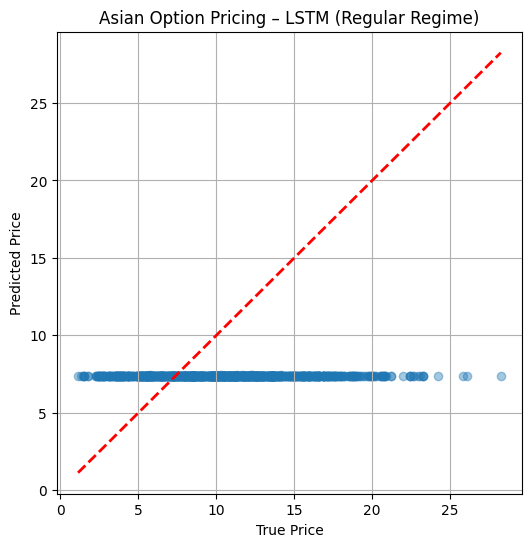

In [ ]:
#  SCATTER PLOT: TRUE VS PREDICTED (ASIAN LSTM)

import matplotlib.pyplot as plt

true_vals = df_asian_reg["price"].values
pred_vals = []

model_lstm.eval()
with torch.no_grad():
    for seq, _ in DataLoader(AsianOptionDataset(seq_reg, true_vals), batch_size=64):
        seq = seq.to(device)
        out = model_lstm(seq)
        pred_vals.extend(out.cpu().numpy().flatten())

pred_vals = np.array(pred_vals)

plt.figure(figsize=(6, 6))
plt.scatter(true_vals, pred_vals, alpha=0.4)
plt.plot([true_vals.min(), true_vals.max()],
         [true_vals.min(), true_vals.max()],
         "r--", linewidth=2)

plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Asian Option Pricing – LSTM (Regular Regime)")
plt.grid(True)
plt.show()


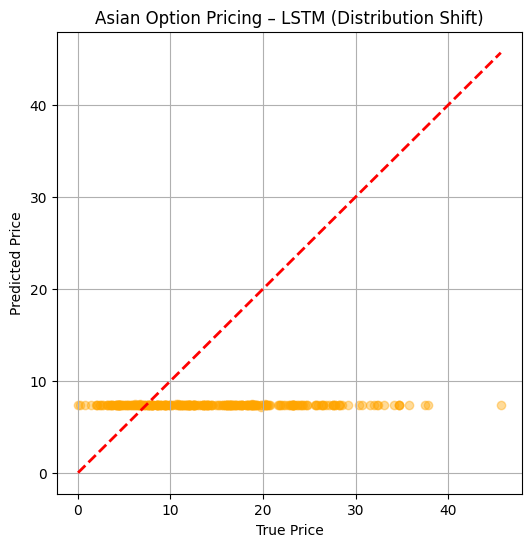

In [ ]:
#  SCATTER PLOT: SHIFTED TEST SET (ASIAN LSTM)

true_vals_shift = df_asian_irreg["price"].values
pred_vals_shift = []

model_lstm.eval()
with torch.no_grad():
    for seq, _ in DataLoader(AsianOptionDataset(seq_irreg, true_vals_shift), batch_size=64):
        seq = seq.to(device)
        out = model_lstm(seq)
        pred_vals_shift.extend(out.cpu().numpy().flatten())

pred_vals_shift = np.array(pred_vals_shift)

plt.figure(figsize=(6, 6))
plt.scatter(true_vals_shift, pred_vals_shift, alpha=0.4, color="orange")
plt.plot([true_vals_shift.min(), true_vals_shift.max()],
         [true_vals_shift.min(), true_vals_shift.max()],
         "r--", linewidth=2)

plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Asian Option Pricing – LSTM (Distribution Shift)")
plt.grid(True)
plt.show()
